### Overview

Clustering of word2vec embeddings of PAM50 genes (gene-level embeddings)

In [1]:
import pandas as pd
import numpy as np
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch
from sklearn.preprocessing import StandardScaler, normalize
from scipy.cluster.hierarchy import fcluster
import os
import random
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
os.environ["OMP_NUM_THREADS"] = "1"

#### 1. Import and prepare data

In [3]:
# import pam50
pam50 = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/pam50gene_list_csv.csv", header=0)

In [4]:
# get pam50 gene list
pam50_geneList = pam50['new_gene_symbol'].tolist()

In [5]:
# import tpm counts train data
train_data = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/SCANB_GSE202203/scanb_hiseq_train_test_sets/train_test_80_20/SCANB_HiSeq_pam50gene_tpm_counts_subtype_train_80.csv", 
                          header=0, index_col=0)

In [6]:
# keep only PAM50 gene counts in the train set
X_train = train_data.iloc[:, 0:50]
X_train.shape

(2204, 50)

In [7]:
# check is column names in X_train match with the ensembl ids in pam50
X_train.columns.tolist() == pam50['ensembl_gene_id'].tolist()

True

In [8]:
# rename the column names as gene symbols
X_train.columns = pam50_geneList

#### 2. Train Word2vec using SVM-optimized parameters

In [9]:
# function to rank gene column names to create gene sentence
def get_top_genes(row):
    return row.sort_values(ascending=False).index.to_list()

In [10]:
# function to get average embedding
# need to average the word embeddings because it creates a fixed-length single vector representation for the entire sequence
# useful for machine learning models which needs a single input vector for each sample
# Word2vec creates (m,n) embedding vector for each sequence (m: number of words in the sequence, n: embedding vector size)
# each word has an embedding of shape (vector size,)
# the average of the embeddings have to be computed column wise to maintain the shape of embedding vector size
# averaging the mean row-wise is incorrect, because it reduces the embedding of an entire word into a single value.
def get_average_vector(sequence, model):
    vectors = [model.wv[word] for word in sequence if word in model.wv]
    # return a zero vector if no valid words
    if len(vectors) == 0:
        return np.zeros(model.vector_size)  
    return np.mean(vectors, axis=0)

In [11]:
# rank the gene names for all the samples in X_train
X_train_ranked_geneList = X_train.apply(lambda row: get_top_genes(row), axis=1)
X_train_ranked_geneList = pd.DataFrame(X_train_ranked_geneList , index=X_train.index, columns=['ranked_gene_list'])

In [12]:
X_train_ranked_geneList.shape

(2204, 1)

In [13]:
seed = 42
np.random.seed(seed)
random.seed(seed)

In [14]:
# train word2vec using parameters optimized for SVM
w2v_model_svm = Word2Vec(X_train_ranked_geneList['ranked_gene_list'], vector_size=600, sg=1, alpha=0.01, window=5, epochs=5,
                         seed=seed, workers=1)

In [15]:
# get word2vec embedding for each gene
pam50_vec = [w2v_model_svm.wv[gene] for gene in pam50_geneList if gene in w2v_model_svm.wv]
pam50_vec[0][0:3]

array([0.00571237, 0.0115963 , 0.08912588], dtype=float32)

In [16]:
# check if the vectors are l2 normalized
np.linalg.norm(pam50_vec, axis=1)

array([1.3332994, 1.5045298, 1.4017013, 1.1733505, 1.3607566, 1.7290279,
       1.3776602, 1.8522776, 1.3577094, 1.5443507, 1.6870769, 1.140609 ,
       1.3741944, 1.5956347, 1.6992478, 1.3373668, 1.8764218, 1.5668662,
       1.7851533, 1.387189 , 1.8555211, 1.4777408, 1.1872224, 1.2097248,
       1.444379 , 1.7349408, 1.3108205, 1.3062631, 1.2525684, 1.3162628,
       1.1742542, 1.6373681, 1.3284364, 1.4851434, 1.7824202, 1.9027945,
       1.2745415, 1.1972772, 1.3353986, 1.8224863, 1.1613213, 1.2740241,
       1.3731587, 1.3336498, 1.140401 , 1.9570345, 1.1846566, 1.3325276,
       1.4219548, 1.3470833], dtype=float32)

In [17]:
# l2 normalize the word vectors, as they are not
pam50_vec_normalized = normalize(pam50_vec)
pam50_vec_normalized[0][0:3]

array([0.00428438, 0.00869745, 0.06684611])

In [18]:
# check if the vectors are l2 normalized (magnitude = 1)
np.linalg.norm(pam50_vec_normalized, axis=1)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [19]:
# convert the standardized vectors into a df
pam50_vec_df = pd.DataFrame(pam50_vec_normalized, index=pam50_geneList)

#### 3. Hierarchical Clustering using Cosine Distance

In [20]:
# hierarchical clustering
Z = sch.linkage(pam50_vec, metric='cosine', method='average')

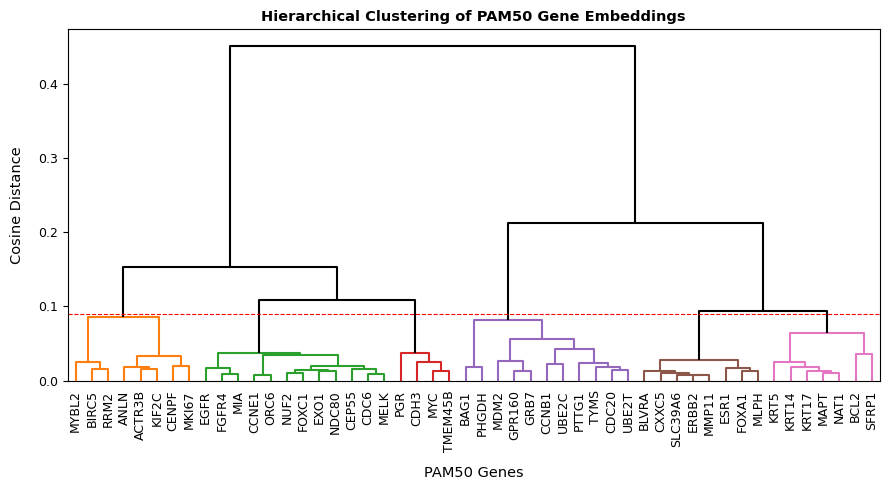

In [21]:
# plot dendogram
plt.figure(figsize=(9, 5))
dendogram = sch.dendrogram(Z, labels=pam50_vec_df.index, leaf_rotation=90, color_threshold=0.09, above_threshold_color='black')
plt.title('Hierarchical Clustering of PAM50 Gene Embeddings', fontdict={'size':10.5, 'color': 'black', 'family':'sans-serif', 'weight':'bold'})
plt.xlabel('PAM50 Genes', labelpad=10, fontdict={'size':10.5, 'color': 'black', 'family':'sans-serif'})
plt.ylabel('Cosine Distance', labelpad=10,  fontdict={'size':10.5, 'color': 'black', 'family':'sans-serif'})
plt.xticks(fontsize=9, color='black')
plt.yticks(fontsize=9, color='black')
plt.tight_layout()
plt.axhline(y=0.09, color='red', linestyle='--', linewidth=0.8)
# plt.savefig('hierarchical_clustering_pam50_word2vec_without_legend.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
# define a colormap for 6 clusters based on dendogram cluster colors
cmap_dendogram = {1: '#FF7D0B', #orange shade
        2: '#63B863', #green shade
        3: '#DC4647', #red shade
        4: '#BC9FD5', #light purple shade
        5: '#854C41', #brown shade
        6: '#F2BEE2', #pink shade
       }

In [23]:
# get cluster labels and add it to the pam50 df
pam50['hier_cluster'] = fcluster(Z, t=0.09, criterion='distance')
pam50['hier_cluster'].value_counts()

hier_cluster
2    12
4    11
1     8
5     8
6     7
3     4
Name: count, dtype: int64

In [24]:
# check a cluster
gene_cluster = pam50.loc[pam50['hier_cluster']==5, 'new_gene_symbol']
for gene in gene_cluster:
    print(gene)

BLVRA
CXXC5
ERBB2
ESR1
FOXA1
MLPH
MMP11
SLC39A6


In [25]:
# save the cluster labels
pam50.to_csv('hierarchical_clusters_pam50_word2vec_embedding.csv')

#### 4. PCA visualization

In [26]:
# pca transformation
pca_pam50 = PCA(n_components=2, random_state=seed)
pcaComponents_pam50 = pca_pam50.fit_transform(pam50_vec_normalized)

# convert to DataFrame
pcaComponents_pam50_df = pd.DataFrame(pcaComponents_pam50, columns=["PC1", "PC2"], index=pam50_vec_df.index)

In [27]:
clusters = fcluster(Z, t=0.09, criterion='distance')
pcaComponents_pam50_df['gene_cluster'] = clusters
pcaComponents_pam50_df['gene_cluster'].value_counts()

gene_cluster
2    12
4    11
1     8
5     8
6     7
3     4
Name: count, dtype: int64

In [28]:
# get the variance explained by each PC 
explained_variance = pca_pam50.explained_variance_ratio_

# print variance for each component
for i, var in enumerate(explained_variance):
    print(f"PC{i+1}: {var:.4f} ({var*100:.2f}%) variance explained")

PC1: 0.7239 (72.39%) variance explained
PC2: 0.2208 (22.08%) variance explained


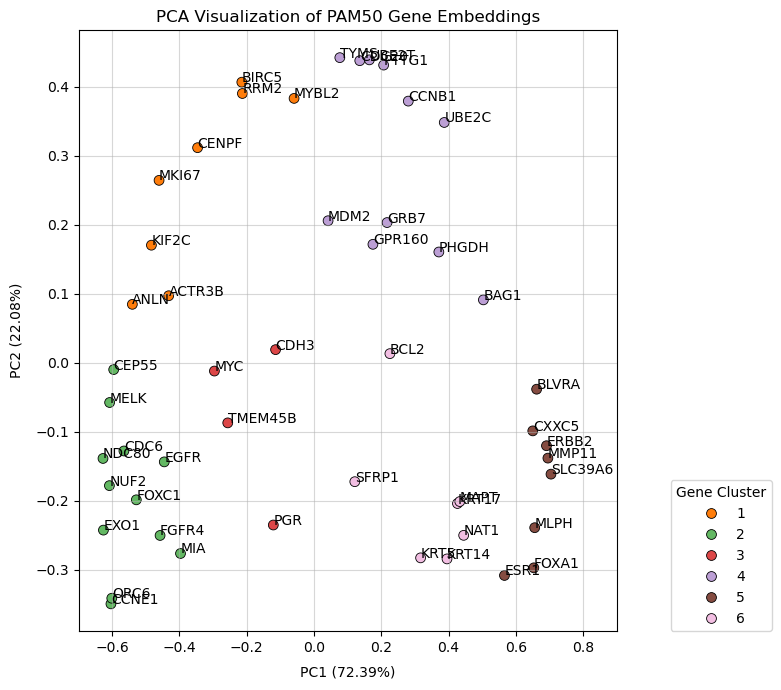

In [29]:
# plot PCA
plt.figure(figsize=(8,7))
sns.scatterplot(
    x=pcaComponents_pam50_df["PC1"], 
    y=pcaComponents_pam50_df["PC2"],
    hue=pcaComponents_pam50_df["gene_cluster"],
    palette=cmap_dendogram, s=50, edgecolor='black', linewidth=0.6
)

# annotate each point with its gene name (index)
for gene, x, y in zip(pcaComponents_pam50_df.index, 
                       pcaComponents_pam50_df["PC1"], 
                       pcaComponents_pam50_df["PC2"]):
    plt.text(x, y, gene, fontsize=10, alpha=1, color='black', rotation=0)
    
plt.xlabel("PC1 (72.39%)", labelpad=8)
plt.ylabel("PC2 (22.08%)", labelpad=8)
plt.xlim(-0.7, 0.9)
plt.title("PCA Visualization of PAM50 Gene Embeddings")
plt.legend(title='Gene Cluster', loc=(1.1,0))
plt.grid(alpha=0.5)
plt.tight_layout()
# plt.savefig('pca_plot_pam50_word2vec_embedding.png', dpi=300, bbox_inches='tight')
plt.show()